In [5]:
import pandas as pd
import glob

path = r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\raw\fashion\*.csv"
files = glob.glob(path)

dfs = []

for file in files:
    df = pd.read_csv(file)

    df = df[['overall','reviewText','reviewTime']]

    df = df.rename(columns={
        'overall':'rating',
        'reviewText':'review_text',
        'reviewTime':'review_time'
    })

    df['source'] = 'amazon_fashion'
    df['item_name'] = 'fashion_product'

    dfs.append(df)

fashion_df = pd.concat(dfs, ignore_index=True)

fashion_df['review_id'] = range(len(fashion_df))

fashion_df = fashion_df[['review_id','source','item_name','review_text','rating','review_time']]

fashion_df.to_csv(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\data\processed\fashion_reviews.csv",index=False)

print("Fashion dataset size:",fashion_df.shape)

Fashion dataset size: (748158, 6)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
import os
import seaborn as sns

# Consistent plot style across all notebooks
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

In [7]:
print(f"Shape: {fashion_df.shape}")
print(fashion_df["rating"].value_counts().sort_index())

Shape: (748158, 6)
rating
-1.0    148812
 0.0     81005
 1.0    518341
Name: count, dtype: int64


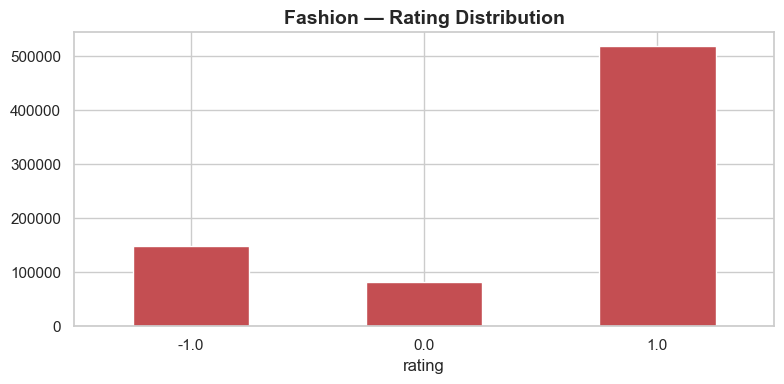

In [8]:
# Cell 2 — Rating Distribution
fig, ax = plt.subplots(figsize=(8, 4))
fashion_df["rating"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#C44E52", edgecolor="white"
)
ax.set_title("Fashion — Rating Distribution", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\fashion\rating_distribution.png", dpi=150)
plt.show()

In [6]:
# Fill missing reviews with an empty string
fashion_df["review_text"] = fashion_df["review_text"].fillna("")

vec = CountVectorizer(stop_words="english", max_features=40)
vec.fit_transform(fashion_df["review_text"])
keywords = vec.get_feature_names_out()
print("Top 40 fashion review keywords:")
print(keywords)

# Domain signals to look for:
# size, fit, small, large, true, runs, quality, material, fabric, comfortable, soft

Top 40 fashion review keywords:
['beautiful' 'big' 'bit' 'bought' 'buy' 'color' 'comfortable' 'cute' 'don'
 'dress' 'expected' 'fit' 'fits' 'good' 'got' 'great' 'just' 'large'
 'like' 'little' 'long' 'look' 'looks' 'love' 'material' 'nice' 'ordered'
 'perfect' 'picture' 'pretty' 'price' 'product' 'quality' 'really' 'shirt'
 'size' 'small' 'time' 'way' 'wear']


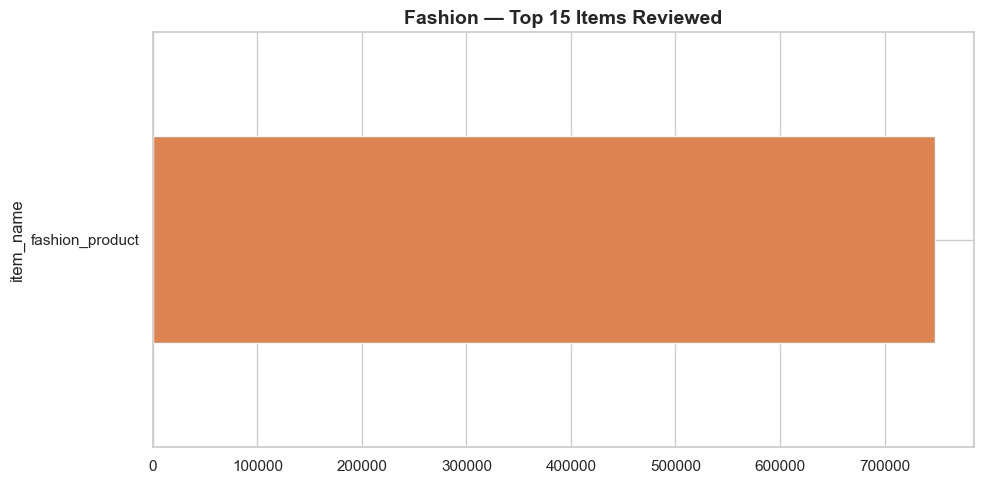

In [9]:
# Cell 3 — Top Item Names
fig, ax = plt.subplots(figsize=(10, 5))
fashion_df["item_name"].value_counts().head(15).plot(
    kind="barh", ax=ax, color="#DD8452"
)
ax.set_title("Fashion — Top 15 Items Reviewed", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\fashion\top_items.png", dpi=150)
plt.show()

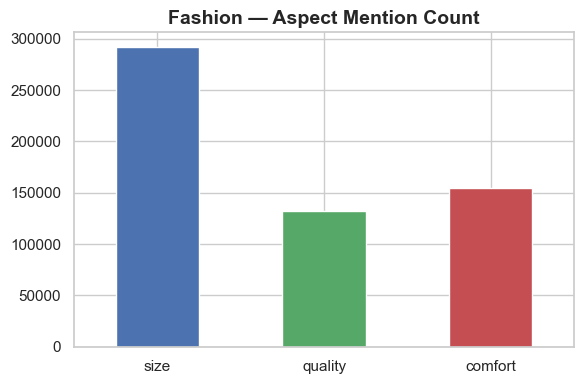

In [10]:
# Cell 4 — Aspect Keywords
aspects = {
    "size"    : ["size","fit","small","large","tight","loose"],
    "quality" : ["quality","material","fabric","stitch","durable"],
    "comfort" : ["comfort","soft","rough","wear","itchy"]
}
counts = {k: fashion_df["review_text"].astype(str).str.lower()
            .apply(lambda x: any(w in x for w in v)).sum()
          for k, v in aspects.items()}

fig, ax = plt.subplots(figsize=(6, 4))
pd.Series(counts).plot(kind="bar", ax=ax,
    color=["#4C72B0","#55A868","#C44E52"], edgecolor="white")
ax.set_title("Fashion — Aspect Mention Count", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\fashion\aspect_counts.png", dpi=150)
plt.show()

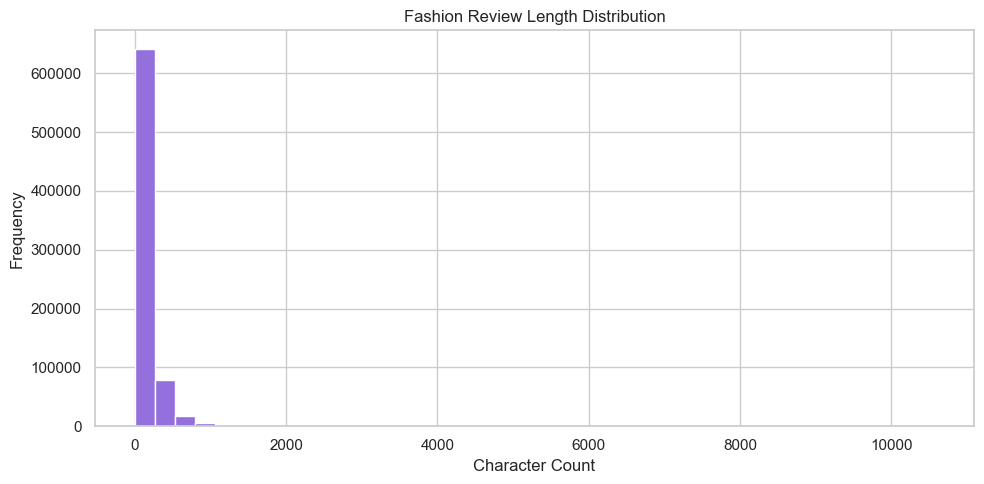

In [7]:
fashion_df["review_length"] = fashion_df["review_text"].str.len()
fashion_df["review_length"].hist(bins=40, color="mediumpurple", edgecolor="white")
plt.title("Fashion Review Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [12]:
#to combine all the tweets
sentences = fashion_df["review_text"].tolist()
len(sentences)

748158

In [13]:
sentences_to_string = " ".join(fashion_df["review_text"].dropna().astype(str).sample(
    min(5000, len(fashion_df))))

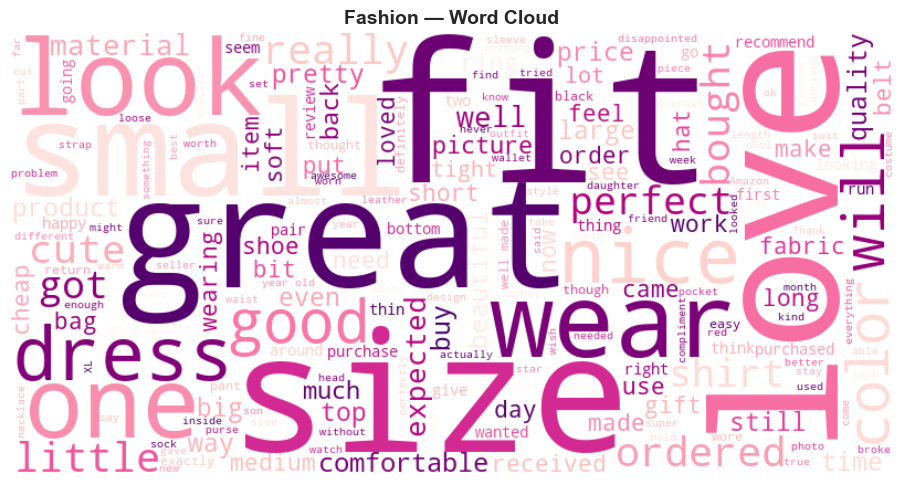


All Fashion EDA images saved to reports/eda/fashion/


In [14]:
from wordcloud import WordCloud
# plt.figure(figsize=(20,20))
wc = WordCloud(width=800, height=400, background_color="white",
               colormap="RdPu", max_words=200).generate(sentences_to_string)
fig, ax = plt.subplots(figsize=(12, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Fashion — Word Cloud", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(r"C:\Users\arnav\Downloads\Sentiment-Intelligence-Engine\notebooks\eda\fashion\wordcloud.png", dpi=150)
plt.show()

print("\nAll Fashion EDA images saved to reports/eda/fashion/")